# XGBoost — Predicción de Salarios en Tecnología
**Dataset:** `datossalarios.xlsx` · 250,000 registros · 10 variables  
**Variable objetivo:** `salario` (USD)

In [1]:
# Instalar si es necesario
# pip install xgboost scikit-learn pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from xgboost import XGBRegressor, plot_importance

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")
print(f"XGBoost version: {xgb.__version__}")

✅ Librerías cargadas correctamente
XGBoost version: 3.2.0


## 1. Carga y exploración del dataset

In [2]:
# ── Cargar el Excel ──────────────────────────────────────────────────────────
df = pd.read_excel("datossalarios.xlsx", sheet_name="salarios")

print("=" * 55)
print("📊 INFORMACIÓN DEL DATASET")
print("=" * 55)
print(f"Shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
df.describe().round(2)

📊 INFORMACIÓN DEL DATASET
Shape: (250000, 10)

Columnas: ['titulo_profesional', 'anios_experiencia', 'nivel_educativo', 'numero_habilidades', 'industria', 'tamaño_empresa', 'ubicación', 'trabajo_remoto', 'certificaciones', 'salario']

Valores nulos:
titulo_profesional    0
anios_experiencia     0
nivel_educativo       0
numero_habilidades    0
industria             0
tamaño_empresa        0
ubicación             0
trabajo_remoto        0
certificaciones       0
salario               0
dtype: int64

Estadísticas descriptivas:


,anios_experiencia,numero_habilidades,certificaciones,salario
count,250000.00,250000.00,250000.00,250000.00
mean,10.01,10.00,2.49,145718.08
std,6.06,5.48,1.71,37407.95
min,0.00,1.00,0.00,31867.00
25%,5.00,5.00,1.00,119358.00
50%,10.00,10.00,2.00,143453.00
75%,15.00,15.00,4.00,169492.00
max,20.00,19.00,5.00,333046.00


In [3]:
# ── Conteos de variables categóricas ────────────────────────────────────────
cat_cols = ['titulo_profesional', 'nivel_educativo', 'industria',
            'tamaño_empresa', 'ubicación', 'trabajo_remoto']

for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} categorías):")
    print(df[col].value_counts().to_string())


titulo_profesional (12 categorías):
titulo_profesional
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633

nivel_educativo (5 categorías):
nivel_educativo
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776

industria (10 categorías):
industria
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841

tamaño_empresa (5 categorías):
tamaño_empresa
Large         50254
Small         50235
Medium        5

## 2. Visualización exploratoria

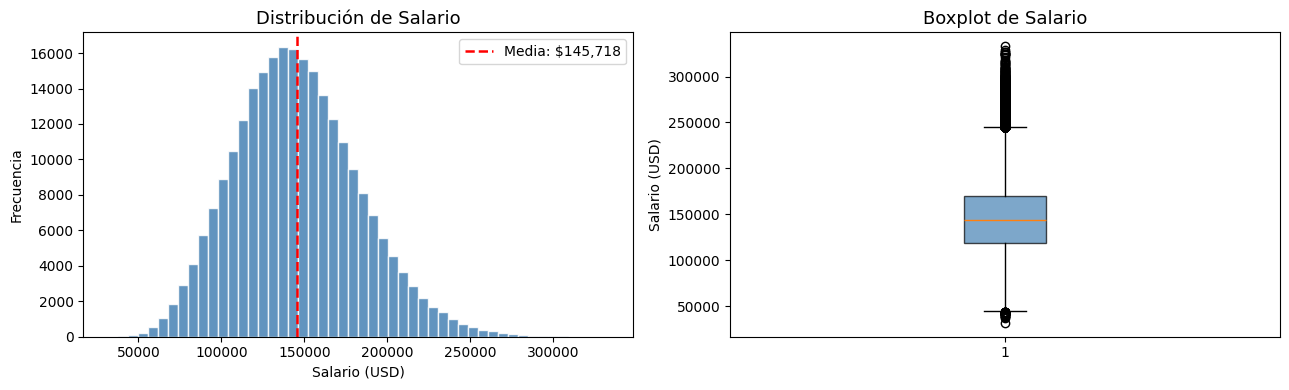

In [4]:
# ── Distribución de la variable objetivo ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['salario'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['salario'].mean(), color='red', linestyle='--',
                linewidth=1.8, label=f"Media: ${df['salario'].mean():,.0f}")
axes[0].set_title('Distribución de Salario', fontsize=13)
axes[0].set_xlabel('Salario (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].boxplot(df['salario'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot de Salario', fontsize=13)
axes[1].set_ylabel('Salario (USD)')

plt.tight_layout()
plt.show()

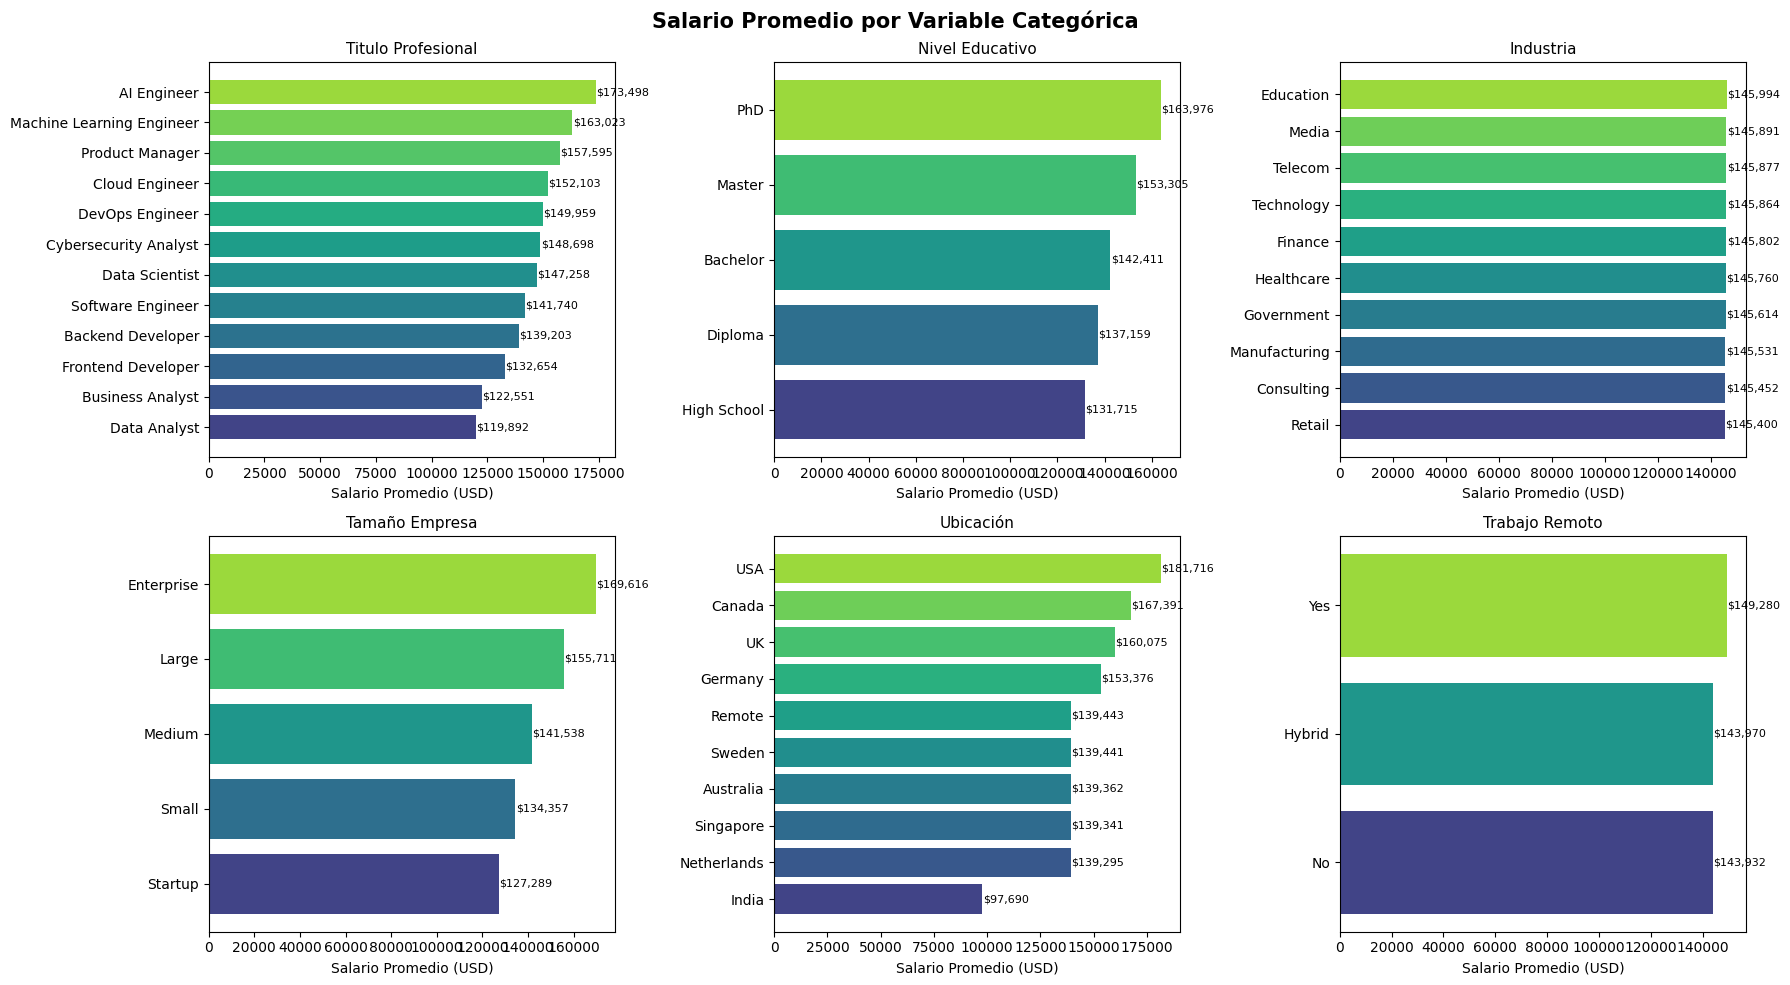

In [5]:
# ── Salario promedio por variable categórica ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Salario Promedio por Variable Categórica", fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    medias = df.groupby(col)['salario'].mean().sort_values()
    bars = ax.barh(medias.index, medias.values,
                   color=plt.cm.viridis(np.linspace(0.2, 0.85, len(medias))))
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Salario Promedio (USD)')
    for bar, val in zip(bars, medias.values):
        ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

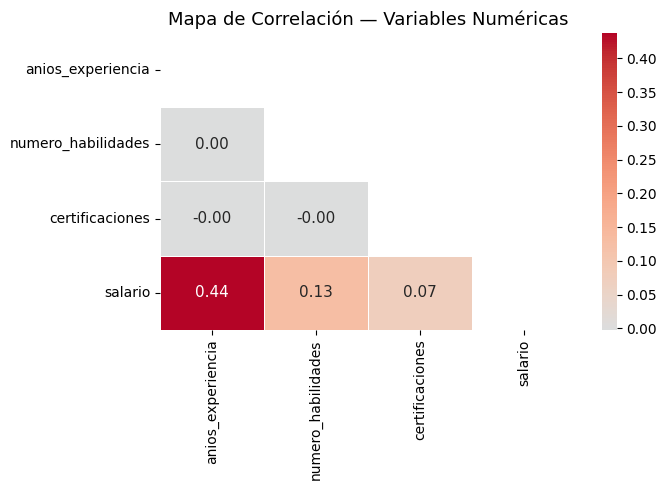

In [6]:
# ── Mapa de correlación (variables numéricas) ────────────────────────────────
num_cols = ['anios_experiencia', 'numero_habilidades', 'certificaciones', 'salario']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    annot_kws={"size": 11}
)
plt.title("Mapa de Correlación — Variables Numéricas", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Preprocesamiento: encoding de variables categóricas

In [7]:
# ── Codificar variables categóricas con OrdinalEncoder ───────────────────────
# XGBoost nativo soporta 'enable_categorical=True' con pd.Categorical,
# pero OrdinalEncoder es más portable con GridSearchCV.

df_enc = df.copy()
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_enc[cat_cols] = enc.fit_transform(df_enc[cat_cols])

# ── Separar features y target ────────────────────────────────────────────────
X = df_enc.drop(columns=['salario'])
y = df_enc['salario']

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Target: salario | Shape: {y.shape}")

# ── Train / Test Split (80/20 estratificado por cuartiles) ───────────────────
# pd.qcut genera etiquetas de cuartil para estratificar en regresión.
y_strat = pd.qcut(y, q=4, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_strat
)

print(f"\n📐 Tamaños:")
print(f"  Train: {X_train.shape[0]:,} muestras")
print(f"  Test : {X_test.shape[0]:,} muestras")

Features (9): ['titulo_profesional', 'anios_experiencia', 'nivel_educativo', 'numero_habilidades', 'industria', 'tamaño_empresa', 'ubicación', 'trabajo_remoto', 'certificaciones']
Target: salario | Shape: (250000,)

📐 Tamaños:
  Train: 200,000 muestras
  Test : 50,000 muestras


## 4. Modelo XGBoost base

In [8]:
# ── Función de métricas ───────────────────────────────────────────────────────
def evaluar_modelo(y_true, y_pred, nombre="Modelo"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{'='*48}")
    print(f"  📈 Resultados — {nombre}")
    print(f"{'='*48}")
    print(f"  RMSE : ${rmse:,.2f}")
    print(f"  MAE  : ${mae:,.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

# ── Modelo con parámetros por defecto ────────────────────────────────────────
xgb_base = XGBRegressor(
    objective    = 'reg:squarederror',
    random_state = 42,
    n_jobs       = -1,
    verbosity    = 0
)

xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_test)

metricas_base = evaluar_modelo(y_test, y_pred_base, "XGBoost Base")


  📈 Resultados — XGBoost Base
  RMSE : $5,543.68
  MAE  : $4,418.62
  R²   : 0.9782
  MAPE : 3.25%


## 5. Optimización de hiperparámetros (GridSearchCV)

In [9]:
# ── Grid de parámetros ───────────────────────────────────────────────────────
# Nota: con 200,000 filas de train, un grid grande puede tardar bastante.
# Se usa un subconjunto representativo para la búsqueda.
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

xgb_cv = XGBRegressor(
    objective    = 'reg:squarederror',
    random_state = 42,
    n_jobs       = -1,
    verbosity    = 0
)

grid_search = GridSearchCV(
    estimator  = xgb_cv,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

print("🔎 Ejecutando GridSearchCV... (puede tardar varios minutos con 250k filas)")
grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros encontrados:")
for k, v in grid_search.best_params_.items():
    print(f"   {k:22s}: {v}")
print(f"\n   CV RMSE (mejor): ${-grid_search.best_score_:,.2f}")

🔎 Ejecutando GridSearchCV... (puede tardar varios minutos con 250k filas)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Mejores parámetros encontrados:
   colsample_bytree      : 0.8
   learning_rate         : 0.05
   max_depth             : 7
   min_child_weight      : 3
   n_estimators          : 300
   subsample             : 0.8

   CV RMSE (mejor): $5,201.36


## 6. Modelo optimizado

In [10]:
# ── Entrenar con mejores hiperparámetros ─────────────────────────────────────
best_params = grid_search.best_params_

xgb_opt = XGBRegressor(
    **best_params,
    objective             = 'reg:squarederror',
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
    early_stopping_rounds = 20
)

xgb_opt.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_test, y_test)],
    verbose  = False
)

y_pred_opt = xgb_opt.predict(X_test)
metricas_opt = evaluar_modelo(y_test, y_pred_opt, "XGBoost Optimizado")


  📈 Resultados — XGBoost Optimizado
  RMSE : $5,200.27
  MAE  : $4,139.76
  R²   : 0.9808
  MAPE : 3.05%


## 7. Dashboard de resultados

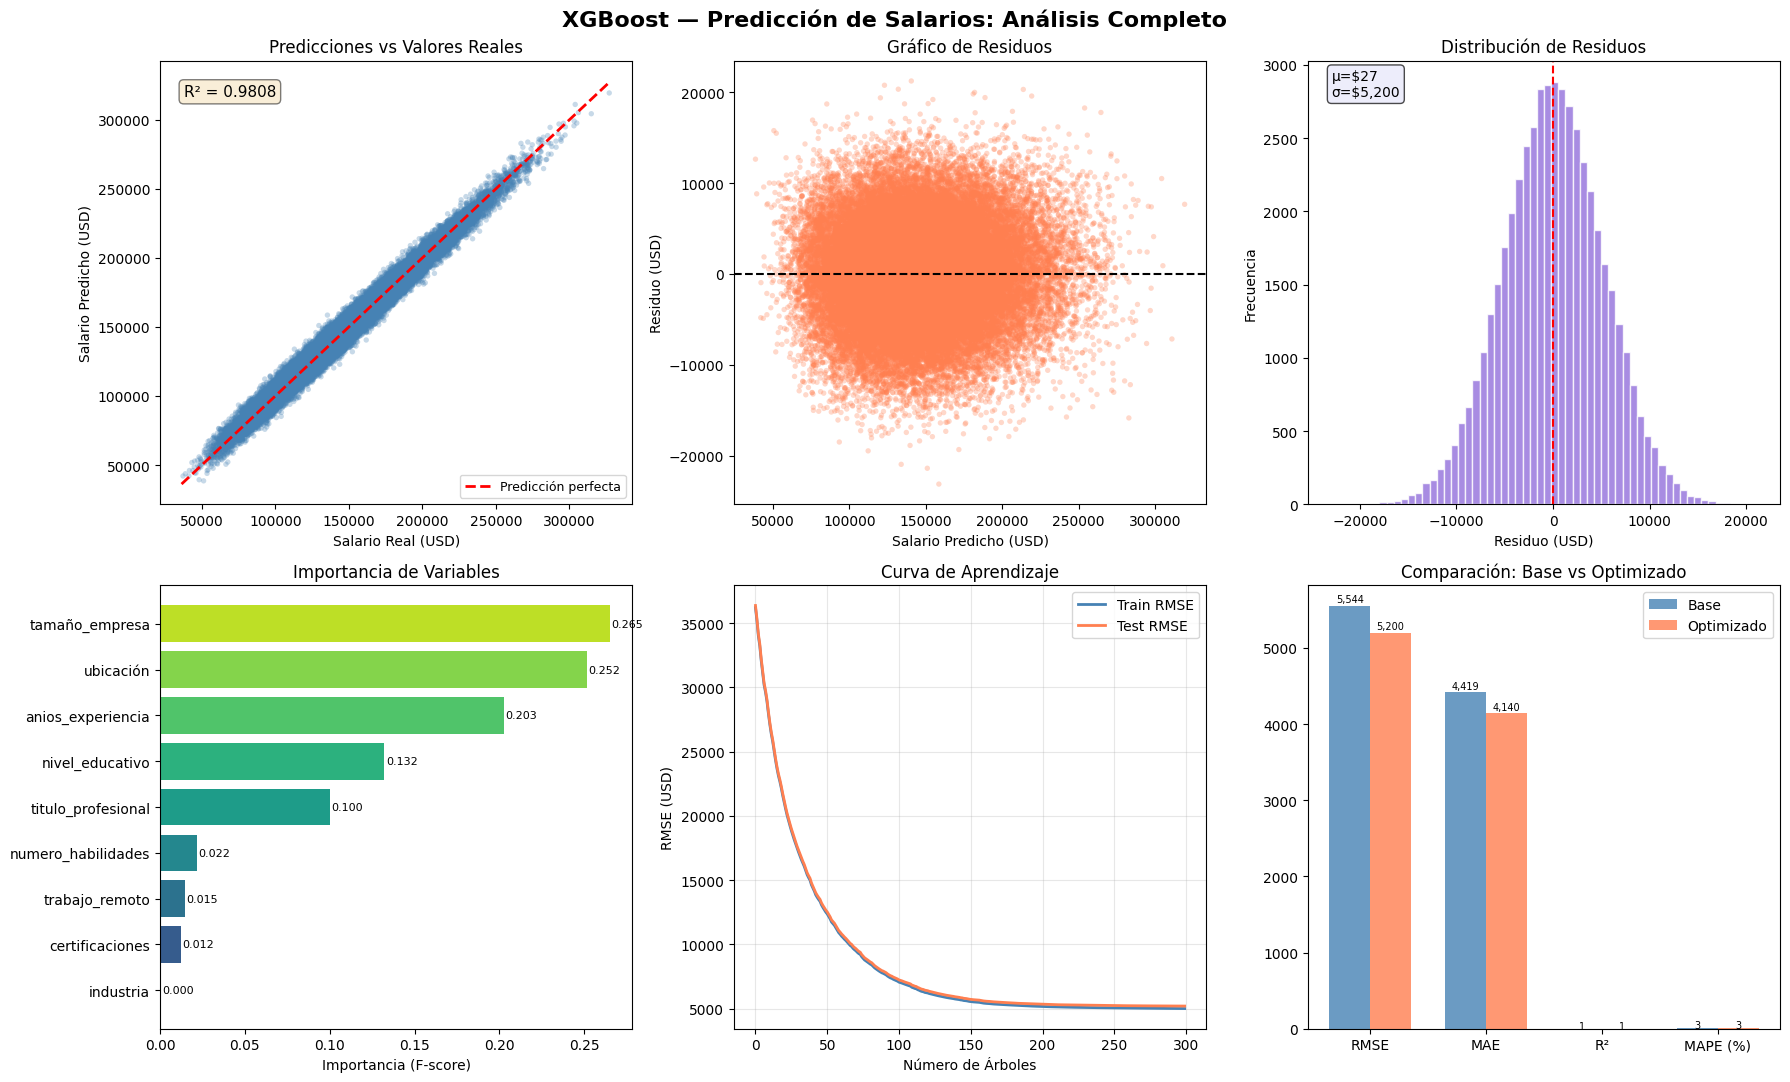

✅ Figura guardada como 'xgboost_salarios_resultados.png'


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("XGBoost — Predicción de Salarios: Análisis Completo",
             fontsize=16, fontweight='bold')

# ── 1. Predicciones vs Valores Reales ────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y_test, y_pred_opt, alpha=0.3, color='steelblue',
           edgecolors='none', s=15)
lims = [min(y_test.min(), y_pred_opt.min()) - 1000,
        max(y_test.max(), y_pred_opt.max()) + 1000]
ax.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Salario Real (USD)')
ax.set_ylabel('Salario Predicho (USD)')
ax.set_title('Predicciones vs Valores Reales')
ax.legend(fontsize=9)
ax.text(0.05, 0.92, f'R² = {metricas_opt["R2"]:.4f}',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── 2. Residuos ───────────────────────────────────────────────────────────────
ax = axes[0, 1]
residuos = y_test.values - y_pred_opt
ax.scatter(y_pred_opt, residuos, alpha=0.3, color='coral',
           edgecolors='none', s=15)
ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Salario Predicho (USD)')
ax.set_ylabel('Residuo (USD)')
ax.set_title('Gráfico de Residuos')

# ── 3. Distribución de Residuos ───────────────────────────────────────────────
ax = axes[0, 2]
ax.hist(residuos, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residuo (USD)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Residuos')
ax.text(0.05, 0.92, f'μ=${residuos.mean():,.0f}\nσ=${residuos.std():,.0f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.7))

# ── 4. Feature Importance ─────────────────────────────────────────────────────
ax = axes[1, 0]
importances = xgb_opt.feature_importances_
indices     = np.argsort(importances)
sorted_feat = [feature_names[i] for i in indices]
sorted_imp  = importances[indices]

bars = ax.barh(sorted_feat, sorted_imp,
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_feat))))
ax.set_xlabel('Importancia (F-score)')
ax.set_title('Importancia de Variables')
for bar, val in zip(bars, sorted_imp):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

# ── 5. Curva de Aprendizaje ───────────────────────────────────────────────────
ax = axes[1, 1]
results = xgb_opt.evals_result()
epochs  = len(results['validation_0']['rmse'])
x_axis  = range(epochs)

ax.plot(x_axis, results['validation_0']['rmse'],
        label='Train RMSE', color='steelblue', linewidth=2)
ax.plot(x_axis, results['validation_1']['rmse'],
        label='Test RMSE',  color='coral',     linewidth=2)
ax.set_xlabel('Número de Árboles')
ax.set_ylabel('RMSE (USD)')
ax.set_title('Curva de Aprendizaje')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 6. Comparación Base vs Optimizado ────────────────────────────────────────
ax = axes[1, 2]
metricas_labels = ['RMSE', 'MAE', 'R²', 'MAPE (%)']
base_vals = [metricas_base['RMSE'], metricas_base['MAE'],
             metricas_base['R2'],   metricas_base['MAPE']]
opt_vals  = [metricas_opt['RMSE'],  metricas_opt['MAE'],
             metricas_opt['R2'],    metricas_opt['MAPE']]

x_pos = np.arange(len(metricas_labels))
width = 0.35
ax.bar(x_pos - width/2, base_vals, width, label='Base',       color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, opt_vals,  width, label='Optimizado', color='coral',     alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(metricas_labels)
ax.set_title('Comparación: Base vs Optimizado')
ax.legend()
for i, (b, o) in enumerate(zip(base_vals, opt_vals)):
    ax.text(i - width/2, b * 1.01, f'{b:,.0f}', ha='center', fontsize=7)
    ax.text(i + width/2, o * 1.01, f'{o:,.0f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('xgboost_salarios_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada como 'xgboost_salarios_resultados.png'")

## 8. Validación cruzada final

In [12]:
import copy

# ── Cross-Validation con el modelo optimizado ────────────────────────────────
xgb_opt_cv = copy.deepcopy(xgb_opt)
xgb_opt_cv.set_params(early_stopping_rounds=None)

cv_scores = cross_val_score(
    xgb_opt_cv, X, y,
    cv      = 5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs  = -1
)
rmse_cv = -cv_scores

print("\n" + "=" * 50)
print("  📊 VALIDACIÓN CRUZADA (5-Fold) — XGBoost Optimizado")
print("=" * 50)
for i, r in enumerate(rmse_cv, 1):
    print(f"  Fold {i}: RMSE = ${r:,.2f}")
print(f"  {'─'*38}")
print(f"  Media  : ${rmse_cv.mean():,.2f}")
print(f"  Std    : ${rmse_cv.std():,.2f}")
print(f"  CV del modelo : {(rmse_cv.std()/rmse_cv.mean())*100:.1f}%")


  📊 VALIDACIÓN CRUZADA (5-Fold) — XGBoost Optimizado
  Fold 1: RMSE = $5,184.50
  Fold 2: RMSE = $5,173.97
  Fold 3: RMSE = $5,208.27
  Fold 4: RMSE = $5,200.66
  Fold 5: RMSE = $5,188.23
  ──────────────────────────────────────
  Media  : $5,191.13
  Std    : $12.10
  CV del modelo : 0.2%


## 9. Predicción de nuevos perfiles

In [13]:
# ── Perfiles a predecir ───────────────────────────────────────────────────────
nuevos_perfiles_raw = pd.DataFrame({
    'titulo_profesional'     : ['Data Scientist',      'AI Engineer',     'Frontend Developer',
                                'Business Analyst',    'Product Manager'],
    'anios_experiencia'      : [5,                     12,                3,
                                8,                     15],
    'nivel_educativo'        : ['Master',              'PhD',             'Bachelor',
                                'Bachelor',            'Master'],
    'numero_habilidades'     : [10,                    15,                7,
                                9,                     12],
    'industria'              : ['Healthcare',          'Telecom',         'Retail',
                                'Finance',             'Technology'],
    'tamaño_empresa'         : ['Large',               'Enterprise',      'Startup',
                                'Medium',              'Large'],
    'ubicación'              : ['USA',                 'Canada',          'India',
                                'Australia',           'USA'],
    'trabajo_remoto'         : ['Yes',                 'Hybrid',          'No',
                                'Hybrid',              'Yes'],
    'certificaciones'        : [3,                     5,                 1,
                                2,                     4]
})

etiquetas = [
    "Data Scientist (5 años, Healthcare)",
    "AI Engineer senior (PhD, remoto)",
    "Frontend junior en startup",
    "Business Analyst (Finance, híbrido)",
    "Product Manager experimentado (USA)"
]

# ── Aplicar el mismo encoding ─────────────────────────────────────────────────
nuevos_enc = nuevos_perfiles_raw.copy()
nuevos_enc[cat_cols] = enc.transform(nuevos_enc[cat_cols])

predicciones = xgb_opt.predict(nuevos_enc)

# ── Mostrar resultados ────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  📊 PREDICCIONES — Perfiles de Ejemplo")
print("=" * 62)

for etiq, pred in zip(etiquetas, predicciones):
    print(f"  {etiq:<42} → ${pred:>10,.0f} USD")


  📊 PREDICCIONES — Perfiles de Ejemplo
  Data Scientist (5 años, Healthcare)        → $   193,118 USD
  AI Engineer senior (PhD, remoto)           → $   270,463 USD
  Frontend junior en startup                 → $    60,155 USD
  Business Analyst (Finance, híbrido)        → $   102,610 USD
  Product Manager experimentado (USA)        → $   247,196 USD


## 10. Análisis de un perfil en contexto

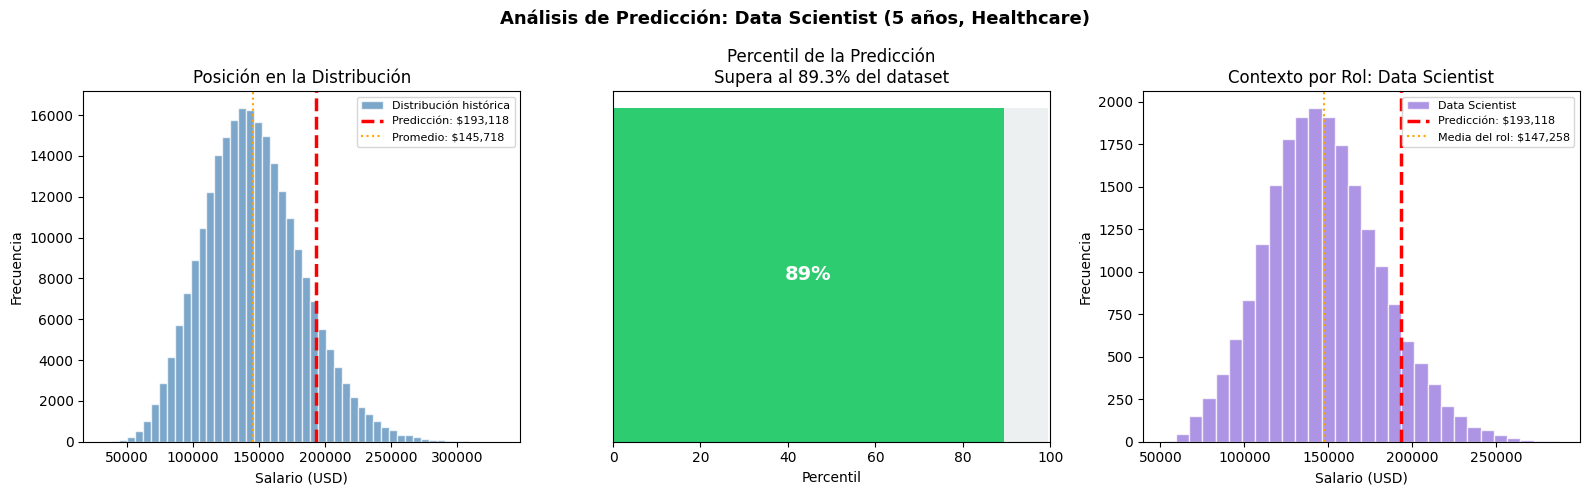

✅ Figura guardada como 'prediccion_salario_perfil.png'


In [14]:
def visualizar_prediccion_salario(salario_pred, etiqueta, titulo_profesional):
    """Muestra la predicción de salario en contexto con el dataset completo."""

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Análisis de Predicción: {etiqueta}",
                 fontsize=13, fontweight='bold')

    # ── 1. Salario en la distribución histórica ───────────────────────────────
    ax = axes[0]
    ax.hist(y, bins=50, color='steelblue', alpha=0.7,
            edgecolor='white', label='Distribución histórica')
    ax.axvline(salario_pred, color='red', linewidth=2.5, linestyle='--',
               label=f'Predicción: ${salario_pred:,.0f}')
    ax.axvline(y.mean(), color='orange', linewidth=1.5, linestyle=':',
               label=f'Promedio: ${y.mean():,.0f}')
    ax.set_xlabel('Salario (USD)')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Posición en la Distribución')
    ax.legend(fontsize=8)

    # ── 2. Percentil de la predicción ─────────────────────────────────────────
    ax = axes[1]
    percentil = (y < salario_pred).mean() * 100
    colores = ['#2ecc71' if i < percentil else '#ecf0f1' for i in range(100)]
    ax.bar(range(100), [1]*100, color=colores, width=1.0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Percentil')
    ax.set_title(f'Percentil de la Predicción\n'
                 f'Supera al {percentil:.1f}% del dataset')
    ax.set_yticks([])
    ax.text(percentil/2, 0.5, f'{percentil:.0f}%',
            ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

    # ── 3. Comparación con mismo título profesional ────────────────────────────
    ax = axes[2]
    salarios_titulo = df[df['titulo_profesional'] == titulo_profesional]['salario']
    ax.hist(salarios_titulo, bins=30, color='mediumpurple',
            alpha=0.75, edgecolor='white', label=titulo_profesional)
    ax.axvline(salario_pred, color='red', linewidth=2.5, linestyle='--',
               label=f'Predicción: ${salario_pred:,.0f}')
    ax.axvline(salarios_titulo.mean(), color='orange', linewidth=1.5, linestyle=':',
               label=f'Media del rol: ${salarios_titulo.mean():,.0f}')
    ax.set_xlabel('Salario (USD)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Contexto por Rol: {titulo_profesional}')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('prediccion_salario_perfil.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figura guardada como 'prediccion_salario_perfil.png'")

# ── Analizar el primer perfil ─────────────────────────────────────────────────
visualizar_prediccion_salario(
    salario_pred       = predicciones[0],
    etiqueta           = etiquetas[0],
    titulo_profesional = nuevos_perfiles_raw['titulo_profesional'].iloc[0]
)